

 ### Downloading the dataset






In [1]:
import kagglehub
path = kagglehub.dataset_download("florencetushabe/sickle-cell-disease-dataset")

100%|██████████| 253M/253M [00:15<00:00, 16.9MB/s]

Extracting files...


###Installing dependencies

Installs the deep learning stack used throughout the notebook:
- `torch` / `torchvision` — model training and image transforms
- `timm` — pretrained computer-vision backbones (ConvNeXt V2, InceptionNeXt, EfficientNetV2)
- `scikit-learn` — train/test splitting and evaluation metrics
- `matplotlib` / `seaborn` — plotting



In [2]:
pip install torch torchvision timm scikit-learn matplotlib seaborn

Log files

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os, csv
os.makedirs('/content/drive/MyDrive/training_logs', exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Random seed function

In [4]:
   import torch
   seed=42
   torch.cuda.manual_seed_all(seed)



Loads the raw images with `torchvision.datasets.ImageFolder`, which infers class labels from subfolder names (e.g. `Negative/`, `Positive/`). Images are resized to 224×224 (the standard input size for the pretrained backbones used later) and converted to tensors. Prints the discovered class names and total image count as a sanity check.

In [5]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(root=path, transform=transform)
print(full_dataset.classes)
print(len(full_dataset))

['Negative', 'Positive']
991




Counts how many images fall into each class (0 = Negative, 1 = Positive). This dataset is imbalanced, which is why later cells introduce class-weighted loss and a weighted sampler rather than treating both classes equally.

In [6]:
from collections import Counter

labels = [s[1] for s in full_dataset.samples]
counts = Counter(labels)

print(f"Negative (0): {counts[0]} images")
print(f"Positive (1): {counts[1]} images")

Negative (0): 147 images
Positive (1): 844 images


### Initial train/test split (unstratified)

A first-pass 70/30 split using plain `train_test_split` with no `stratify` argument. Because the classes are imbalanced, a random split like this can skew the class ratio between train and test.

In [7]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader

indices = list(range(len(full_dataset)))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.3,
    random_state=42
)

train_dataset = Subset(full_dataset, train_idx)
test_dataset = Subset(full_dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train: {len(train_dataset)} images")
print(f"Test: {len(test_dataset)} images")

Train: 693 images
Test: 298 images


In [8]:
from collections import Counter

train_labels = [full_dataset.samples[i][1] for i in train_idx]
test_labels = [full_dataset.samples[i][1] for i in test_idx]

print("Train class counts:", Counter(train_labels))
print("Test class counts:", Counter(test_labels))

Train class counts: Counter({1: 590, 0: 103})
Test class counts: Counter({1: 254, 0: 44})


###Copy dataset to a writable location

The Kaggle Hub cache (`path`) is **read-only**, but the cleanup steps below need to delete corrupted/duplicate files in place. This cell copies the entire dataset to a writable working directory (`/content/sickle_cell_dataset`), wiping any previous copy first so re-running the notebook starts clean.

In [9]:
import shutil
import os

source_path = path

# New writable working copy
working_path = "/content/sickle_cell_dataset"

if os.path.exists(working_path):
    shutil.rmtree(working_path)

shutil.copytree(source_path, working_path)

print(f"Copied dataset to writable location: {working_path}")

Copied dataset to writable location: /content/sickle_cell_dataset


 Scan for corrupted and duplicate images (read-only pass)

Walks the original dataset (`path`) and for every file:
1. Opens it with PIL and calls `.verify()` to catch corrupted/unreadable images.
2. Computes an MD5 hash of the file bytes to detect exact-duplicate images (same picture saved twice, possibly under different filenames).

This first pass is diagnostic only — it reports counts and prints examples but doesn't delete anything yet.

In [10]:
import os
from PIL import Image
import hashlib

def find_corrupted_and_duplicates(root_dir):
    corrupted = []
    hashes = {}
    duplicates = []

    for subdir, _, files in os.walk(root_dir):
        for fname in files:
            fpath = os.path.join(subdir, fname)
            try:
                img = Image.open(fpath)
                img.verify()  # checks file integrity without fully loading
            except Exception:
                corrupted.append(fpath)
                continue

            # Duplicate check via file hash
            with open(fpath, 'rb') as f:
                file_hash = hashlib.md5(f.read()).hexdigest()
            if file_hash in hashes:
                duplicates.append((fpath, hashes[file_hash]))
            else:
                hashes[file_hash] = fpath

    return corrupted, duplicates

corrupted, duplicates = find_corrupted_and_duplicates(path)
print(f"Corrupted images: {len(corrupted)}")
print(f"Duplicate pairs: {len(duplicates)}")

for f in corrupted:
    print("CORRUPTED:", f)
for f1, f2 in duplicates[:5]:
    print("DUPLICATE:", f1, "==", f2)

Corrupted images: 0
Duplicate pairs: 4
DUPLICATE: /root/.cache/kagglehub/datasets/florencetushabe/sickle-cell-disease-dataset/versions/13/Negative/Clear/141.jpg == /root/.cache/kagglehub/datasets/florencetushabe/sickle-cell-disease-dataset/versions/13/Negative/Clear/144.jpg
DUPLICATE: /root/.cache/kagglehub/datasets/florencetushabe/sickle-cell-disease-dataset/versions/13/Negative/Clear/143.jpg == /root/.cache/kagglehub/datasets/florencetushabe/sickle-cell-disease-dataset/versions/13/Negative/Clear/142.jpg
DUPLICATE: /root/.cache/kagglehub/datasets/florencetushabe/sickle-cell-disease-dataset/versions/13/Positive/Labelled/35.jpg == /root/.cache/kagglehub/datasets/florencetushabe/sickle-cell-disease-dataset/versions/13/Positive/Unlabelled/35.jpg
DUPLICATE: /root/.cache/kagglehub/datasets/florencetushabe/sickle-cell-disease-dataset/versions/13/Positive/Labelled/155.jpg == /root/.cache/kagglehub/datasets/florencetushabe/sickle-cell-disease-dataset/versions/13/Positive/Unlabelled/155.jpg


In [11]:
corrupted, duplicates = find_corrupted_and_duplicates(working_path)
print(f"Corrupted images: {len(corrupted)}")
print(f"Duplicate pairs: {len(duplicates)}")

Corrupted images: 0
Duplicate pairs: 4


###Remove duplicate images

Deletes every file identified as a duplicate in the previous cell, keeping only the first occurrence of each unique image (by hash). The existence check guards against trying to delete a file twice if it appeared in more than one duplicate pair.

In [12]:
for fpath, _ in duplicates:
    if os.path.exists(fpath):
        os.remove(fpath)
    else:
        print(f"Already removed, skipping: {fpath}")



Standard inference/training preprocessing for pretrained ImageNet-style backbones:
- Resize to 224×224
- Force RGB
- Convert to tensor
- Normalize using ImageNet's channel mean/std

In [13]:
from torchvision import transforms

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])



Re-loads `ImageFolder` — this time pointed at `working_path` (post cleanup) with the normalization pipeline applied — and reprints the total image count and class distribution to confirm how many images survived the cleanup.

In [14]:
from torchvision import datasets
from collections import Counter

full_dataset = datasets.ImageFolder(root=working_path, transform=preprocess)

labels = [s[1] for s in full_dataset.samples]
print(f"Total images after cleanup: {len(full_dataset)}")
print(Counter(labels))

Total images after cleanup: 987
Counter({1: 842, 0: 145})


### Visualize sample images

Since the tensors are normalized (mean/std shifted), `denormalize()` reverses that transform so the images display with natural colors. Plots 8 images spread evenly across the dataset with their class label as the title - a quick visual sanity check that labels and images line up correctly.

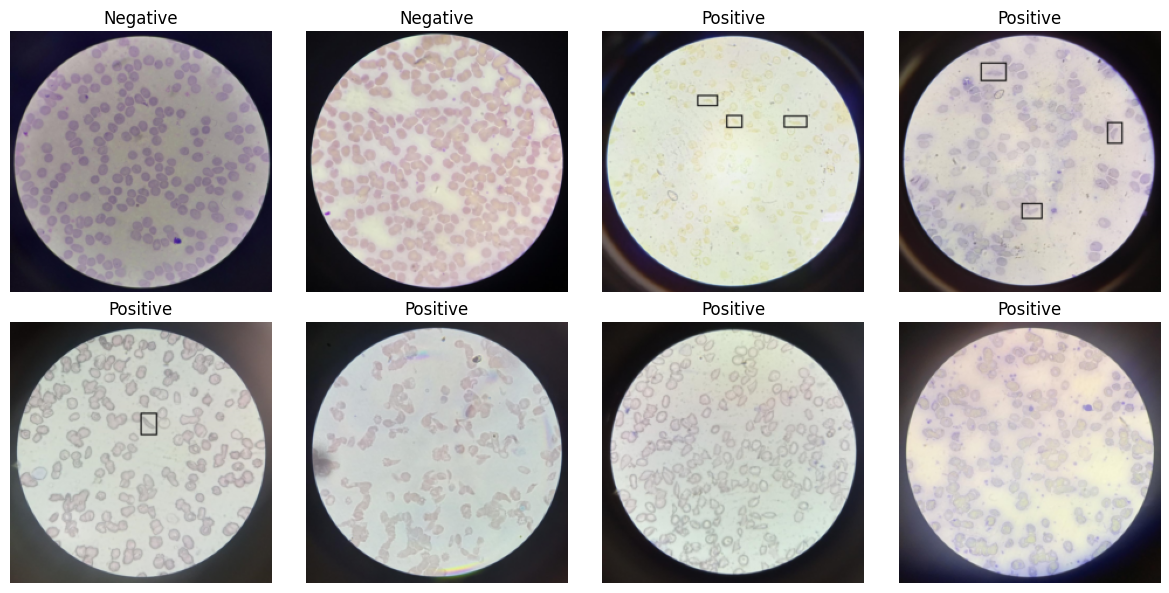

In [15]:
import matplotlib.pyplot as plt
import torch

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return tensor * std + mean

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    idx = i * (len(full_dataset) // 8)
    img, label = full_dataset[idx]
    img_display = denormalize(img).permute(1, 2, 0).clamp(0, 1)
    ax.imshow(img_display)
    ax.set_title(full_dataset.classes[label])
    ax.axis('off')
plt.tight_layout()
plt.show()

### Stratified train/test split

Repeats the 70/30 split, but this time with `stratify=labels`, which guarantees the train and test sets preserve the same class ratio as the full dataset. This corrects the imbalance risk from the earlier unstratified split.

In [16]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader

indices = list(range(len(full_dataset)))
labels = [s[1] for s in full_dataset.samples]

train_idx, test_idx = train_test_split(
    indices, test_size=0.3, stratify=labels, random_state=42
)

train_dataset = Subset(full_dataset, train_idx)
test_dataset = Subset(full_dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

Train: 690 | Test: 297


### Define training-time augmentation

Builds two separate transform pipelines:
- `train_transform` — aggressive augmentation (flips, rotation, random-resized crop, color jitter, small affine shifts, plus a touch of Gaussian noise) to help the model generalize and reduce overfitting on a relatively small medical-imaging dataset.
- `test_transform` — resize + normalize only, with **no augmentation**, since evaluation should reflect the true, unmodified image.

In [17]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Lambda(lambda t: t + torch.randn_like(t) * 0.02),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Test set
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

###  Build train/test datasets with different transforms

Because a single `ImageFolder` object can only carry one transform, the same folder is loaded twice — once with `train_transform` and once with `test_transform`. The stratified split indices (`train_idx` / `test_idx`) are then applied via `Subset` so training samples get augmentation and test samples stay clean.

In [18]:
from torchvision import datasets
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import train_test_split

# Two versions of the same underlying dataset, different transforms
train_dataset_full = datasets.ImageFolder(root=working_path, transform=train_transform)
test_dataset_full = datasets.ImageFolder(root=working_path, transform=test_transform)

labels = [s[1] for s in train_dataset_full.samples]
indices = list(range(len(train_dataset_full)))

train_idx, test_idx = train_test_split(
    indices, test_size=0.3, stratify=labels, random_state=42
)

train_dataset = Subset(train_dataset_full, train_idx)   # augmented
test_dataset = Subset(test_dataset_full, test_idx)       # clean, no augmentation

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

Train: 690 | Test: 297


### Visualize augmentation effects

Takes a single training image (`train_idx[2]`) and displays it 8 times, showing a different random augmentation outcome each time it's fetched through `train_dataset_full`. Useful for confirming the augmentation pipeline is behaving as intended (not too mild, not too destructive).

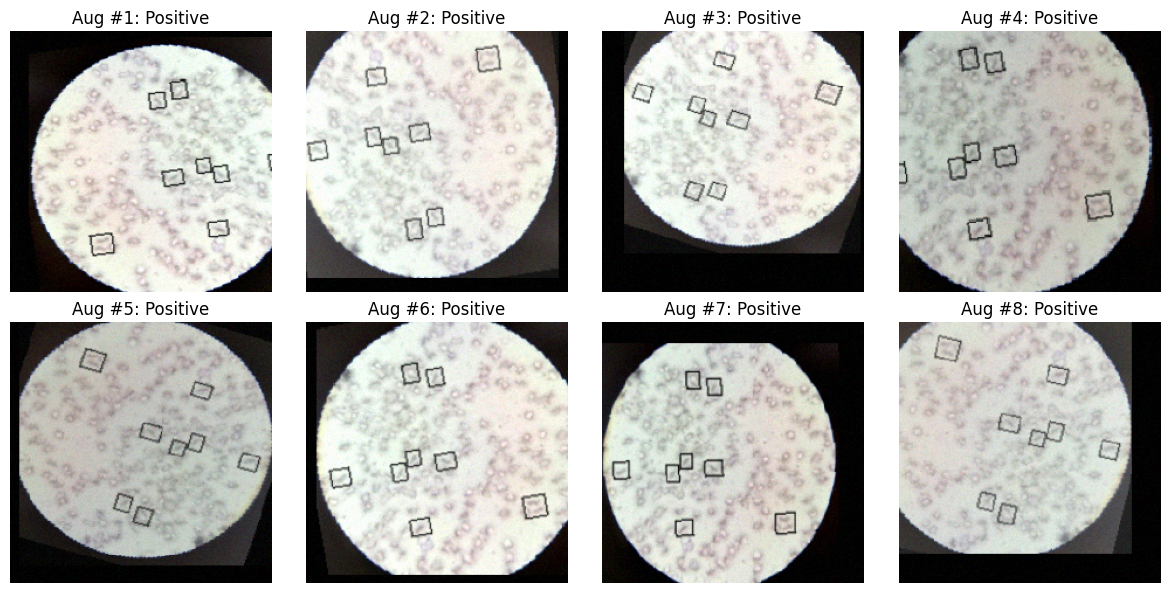

In [19]:
import matplotlib.pyplot as plt
import torch

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return tensor * std + mean

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
sample_idx = train_idx[2]  # same image, augmented 8 different times
for i, ax in enumerate(axes.flat):
    img, label = train_dataset_full[sample_idx]
    img_display = denormalize(img).permute(1, 2, 0).clamp(0, 1)
    ax.imshow(img_display)
    ax.set_title(f"Aug #{i+1}: {train_dataset_full.classes[label]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [20]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


 Robust model loading helper

`timm.create_model` downloads pretrained weights from the Hugging Face Hub, which can intermittently fail (rate limits, network blips). `safe_create_model` retries up to 5 times with a 10-second pause between attempts before giving up.

In [21]:
import time

def safe_create_model(model_name, **kwargs):
    for attempt in range(5):
        try:
            return timm.create_model(model_name, **kwargs)
        except Exception as e:
            print(f"Attempt {attempt+1} failed: {e}")
            time.sleep(10)
    raise RuntimeError(f"Failed to load {model_name} after 5 attempts")

 Model builder with optional frozen backbone



In [22]:
def build_model_with_dropout(model_name, dropout=0.0, num_classes=2, freeze_backbone=True):
    model = safe_create_model(model_name, pretrained=True, num_classes=num_classes, drop_rate=dropout)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
        for param in model.get_classifier().parameters():
            param.requires_grad = True
    return model.to(device)

###  Instantiate the three candidate architectures

Builds three different pretrained backbones (fully fine-tunable, no freezing) to compare against each other for this classification task:
- ConvNeXt V2
- InceptionNeXt
- EfficientNetV2

All are loaded with `pretrained=True` and a 2-unit output head, then moved to `device`.

In [23]:
import timm

def build_model(model_name, num_classes=2):
    model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
    return model.to(device)

# Model 1: ConvNeXt V2
model_convnext = build_model("hf-hub:timm/convnextv2_tiny.fcmae_ft_in22k_in1k")

# Model 2: InceptionNeXt
model_inceptionnext = build_model("hf-hub:timm/inception_next_tiny.sail_in1k")

# Model 3: EfficientNetV2
model_efficientnet = build_model("hf-hub:timm/efficientnetv2_rw_t.ra2_in1k")

config.json:   0%|          | 0.00/901 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  115MB            

model.safetensors: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/602 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  112MB            

model.safetensors: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/643 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 55.1MB            

model.safetensors: downloading bytes:           |  0.00B            



Prints the total parameter count for each architecture.

In [24]:
for name, model in [("ConvNeXt V2", model_convnext),
                      ("InceptionNeXt", model_inceptionnext),
                      ("EfficientNetV2", model_efficientnet)]:
    num_params = sum(p.numel() for p in model.parameters())
    print(f"{name}: {num_params:,} parameters")

ConvNeXt V2: 27,868,034 parameters
InceptionNeXt: 25,755,290 parameters
EfficientNetV2: 12,626,438 parameters




Runs a batch of 2 random "fake" images through each model in `eval()` mode (no gradient tracking) purely to confirm the output shape is `[batch_size, num_classes]` = `[2, 2]` , to check that every model is wired correctly before any real training begins.

In [25]:
dummy_input = torch.randn(2, 3, 224, 224).to(device)  # batch of 2 fake images

for name, model in [("ConvNeXt V2", model_convnext),
                      ("InceptionNeXt", model_inceptionnext),
                      ("EfficientNetV2", model_efficientnet)]:
    model.eval()
    with torch.no_grad():
        output = model(dummy_input)
    print(f"{name} output shape: {output.shape}")  # should be [2, 2]

ConvNeXt V2 output shape: torch.Size([2, 2])
InceptionNeXt output shape: torch.Size([2, 2])
EfficientNetV2 output shape: torch.Size([2, 2])




Rebuilds the stratified train/test split and augmented/clean dataset pair one more time, ensuring a clean, reproducible starting point (same `random_state=42`) heading into the hyperparameter optimization stage.

In [26]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader
from torchvision import datasets

train_dataset_full = datasets.ImageFolder(root=working_path, transform=train_transform)
test_dataset_full = datasets.ImageFolder(root=working_path, transform=test_transform)

labels = [s[1] for s in train_dataset_full.samples]
indices = list(range(len(train_dataset_full)))

train_idx, test_idx = train_test_split(
    indices, test_size=0.3, stratify=labels, random_state=42
)

train_dataset = Subset(train_dataset_full, train_idx)
test_dataset = Subset(test_dataset_full, test_idx)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

Train: 690 | Test: 297


 Installing Optuna



In [27]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 27.5 MB/s eta 0:00:00


### Pre-cache pretrained weights

Downloads and caches all three model checkpoints once, up front, so that repeated `timm.create_model` calls during hyperparameter search / training don't re-download the same weights from the hub every time (which is slow and can hit rate limits).

In [28]:
# before starting HPO-caches weights locally
model_names_list = [
    "convnextv2_tiny.fcmae_ft_in22k_in1k",
    "inception_next_tiny.sail_in1k",
    "efficientnetv2_rw_t.ra2_in1k",
]

for name in model_names_list:
    print(f"Pre-downloading {name}...")
    _ = timm.create_model(name, pretrained=True, num_classes=2)
    print(f"  done.")

Pre-downloading convnextv2_tiny.fcmae_ft_in22k_in1k...
  done.
Pre-downloading inception_next_tiny.sail_in1k...
  done.
Pre-downloading efficientnetv2_rw_t.ra2_in1k...
  done.


In [29]:
import torch
import torch.nn as nn

# Standard balanced weights
neg_count, pos_count = 147, 844
total = neg_count + pos_count

weight_neg = total / (2 * neg_count)
weight_pos = total / (2 * pos_count)

class_weights_convnext = torch.tensor([weight_neg, weight_pos], dtype=torch.float32).to(device)
criterion_convnext = nn.CrossEntropyLoss(weight=class_weights_convnext)

print("ConvNeXt-specific weights:", class_weights_convnext)



ConvNeXt-specific weights: tensor([3.3707, 0.5871], device='cuda:0')


### Weighted random sampler (alternative imbalance fix)

An alternative or complementary approach to class-weighted loss: `WeightedRandomSampler` oversamples the minority class during training by giving each sample a weight inversely proportional to its class frequency, so each mini-batch is roughly balanced regardless of the underlying imbalance.

In [30]:
from torch.utils.data import WeightedRandomSampler

def make_weighted_sampler(subset_indices, all_labels):
    subset_labels = [all_labels[i] for i in subset_indices]
    class_counts = Counter(subset_labels)
    sample_weights = [1.0 / class_counts[label] for label in subset_labels]
    return WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

### Evaluation with balanced accuracy

Standard accuracy can be misleading on imbalanced data (a model predicting "Positive" every time could still score ~85% accuracy here). `evaluate_with_balanced_acc` instead computes balanced accuracy — the average of per-class recall , alongside the loss, giving a fairer picture of performance on both classes.

In [31]:
from sklearn.metrics import balanced_accuracy_score

def evaluate_with_balanced_acc(model, loader, criterion):
    model.eval()
    running_loss, total_n = 0.0, 0
    all_labels, all_preds = [], []
    with torch.no_grad():
        for images, labels_batch in loader:
            images, labels_batch = images.to(device), labels_batch.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels_batch)
            running_loss += loss.item() * images.size(0)
            total_n += labels_batch.size(0)
            preds = torch.argmax(outputs, dim=1)
            all_labels.extend(labels_batch.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    return running_loss / total_n, bal_acc

In [32]:

log_path = '/content/drive/MyDrive/training_logs/convnext_cfg1.csv'

with open(log_path, 'w', newline='') as f:
    csv.writer(f).writerow(['epoch', 'train_loss', 'val_loss'])

###  Shared loss + training/eval utilities for hyperparameter search

Sets up the pieces reused across the Optuna hyperparameter search:
- Recomputes class weights and builds the shared `criterion` (weighted cross-entropy).
- `train_one_epoch` — one pass over the training loader with gradient clipping (`max_norm=1.0`) to stabilize training.
- `evaluate` — one pass over a validation/test loader, returning loss and plain accuracy.

These generic versions get reused (and in some cases redefined with extra metrics) by the final training functions below.

In [33]:
import optuna
from sklearn.model_selection import StratifiedKFold
from tqdm.auto import tqdm
import numpy as np
import torch.nn as nn
from torch import optim
import timm
from collections import Counter
from torch.utils.data import Subset, DataLoader


# criterion

class_counts = Counter(labels)
neg_count, pos_count = class_counts[0], class_counts[1]
total = neg_count + pos_count
weight_neg = total / (2 * neg_count)
weight_pos = total / (2 * pos_count)
class_weights = torch.tensor([weight_neg, weight_pos], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)



# train_one_epoch / evaluate

def train_one_epoch(model, loader, optimizer, criterion, clip_grad=1.0):
    model.train()
    running_loss, correct, total_n = 0.0, 0, 0
    for images, labels_batch in loader:
        images, labels_batch = images.to(device), labels_batch.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad)
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels_batch).sum().item()
        total_n += labels_batch.size(0)
    return running_loss / total_n, correct / total_n


def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total_n = 0.0, 0, 0
    with torch.no_grad():
        for images, labels_batch in loader:
            images, labels_batch = images.to(device), labels_batch.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels_batch)
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels_batch).sum().item()
            total_n += labels_batch.size(0)
    return running_loss / total_n, correct / total_n



# Model builder — frozen backbone

def build_model_with_dropout(model_name, dropout=0.0, num_classes=2, freeze_backbone=True):
    model = timm.create_model(
        model_name, pretrained=True, num_classes=num_classes, drop_rate=dropout
    )
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
        for param in model.get_classifier().parameters():
            param.requires_grad = True
    return model.to(device)



# Objective — k-fold CV, with nested tqdm progress bars

def objective(trial, model_builder, model_name, n_folds=2, epochs_per_trial=4):
    lr = trial.suggest_float("lr", 5e-5, 2e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64])
    dropout = trial.suggest_float("dropout", 0.1, 0.5)

    train_labels_subset = [labels[i] for i in train_idx]
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

    fold_val_losses = []

    fold_pbar = tqdm(
        enumerate(skf.split(train_idx, train_labels_subset)),
        total=n_folds,
        desc=f"Trial {trial.number} folds",
        leave=False
    )

    for fold, (fold_train_i, fold_val_i) in fold_pbar:
        fold_train_idx = [train_idx[i] for i in fold_train_i]
        fold_val_idx = [train_idx[i] for i in fold_val_i]

        fold_train_ds = Subset(train_dataset_full, fold_train_idx)
        fold_val_ds = Subset(test_dataset_full, fold_val_idx)

        fold_train_loader = DataLoader(fold_train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
        fold_val_loader = DataLoader(fold_val_ds, batch_size=batch_size, shuffle=False, num_workers=0)

        # frozen backbone during HPO for speed
        model = model_builder(dropout=dropout)
        optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=lr, weight_decay=weight_decay
        )

        epoch_pbar = tqdm(range(epochs_per_trial), desc=f"  Fold {fold} epochs", leave=False)
        for epoch in epoch_pbar:
            train_loss, train_acc = train_one_epoch(model, fold_train_loader, optimizer, criterion)
            epoch_pbar.set_postfix(loss=f"{train_loss:.4f}", acc=f"{train_acc:.4f}")

        val_loss, val_acc = evaluate(model, fold_val_loader, criterion)
        fold_val_losses.append(val_loss)
        fold_pbar.set_postfix(val_loss=f"{val_loss:.4f}")

        del model
        torch.cuda.empty_cache()

    return np.mean(fold_val_losses)


def run_hpo(model_name, timm_name, n_trials=3, n_folds=2, epochs_per_trial=8):
    def builder(dropout):
        return build_model_with_dropout(timm_name, dropout=dropout, num_classes=2, freeze_backbone=True)

    study = optuna.create_study(direction="minimize")

    trial_pbar = tqdm(total=n_trials, desc=f"{model_name} HPO trials")
    def callback(study, trial):
        trial_pbar.update(1)
        trial_pbar.set_postfix(best_loss=f"{study.best_value:.4f}")

    study.optimize(
        lambda trial: objective(trial, builder, model_name, n_folds=n_folds, epochs_per_trial=epochs_per_trial),
        n_trials=n_trials,
        callbacks=[callback]
    )
    trial_pbar.close()

    print(f"\nBest hyperparameters for {model_name}:")
    print(study.best_params)
    print(f"Best validation loss: {study.best_value:.4f}")
    return study.best_params


# Run for all three models

best_params_convnext = run_hpo("ConvNeXt V2", "convnextv2_tiny.fcmae_ft_in22k_in1k")
best_params_inceptionnext = run_hpo("InceptionNeXt", "inception_next_tiny.sail_in1k")
best_params_efficientnet = run_hpo("EfficientNetV2", "efficientnetv2_rw_t.ra2_in1k")





[I 2026-07-22 18:21:21,514] A new study created in memory with name: no-name-9b3cdf4a-a61f-4980-bee9-f310aca0e956


ConvNeXt V2 HPO trials:   0%|          | 0/3 [00:00<?, ?it/s]

Trial 0 folds:   0%|          | 0/2 [00:00<?, ?it/s]

  Fold 0 epochs:   0%|          | 0/8 [00:00<?, ?it/s]

  Fold 1 epochs:   0%|          | 0/8 [00:00<?, ?it/s]

...

Trial 2 folds:   0%|          | 0/2 [00:00<?, ?it/s]

  Fold 0 epochs:   0%|          | 0/8 [00:00<?, ?it/s]

  Fold 1 epochs:   0%|          | 0/8 [00:00<?, ?it/s]

[I 2026-07-22 18:56:14,382] Trial 2 finished with value: 1.234016666205033 and parameters: {'lr': 0.0006103475869224913, 'weight_decay': 0.0023555434036507234, 'batch_size': 64, 'dropout': 0.4269103791562423}. Best is trial 2 with value: 1.234016666205033.



Best hyperparameters for EfficientNetV2:
{'lr': 0.0006103475869224913, 'weight_decay': 0.0023555434036507234, 'batch_size': 64, 'dropout': 0.4269103791562423}
Best validation loss: 1.2340


###  Final training loop — ConvNeXt (balanced-accuracy checkpointing)

A dedicated training routine for the final ConvNeXt model, incorporating fixes to avoid "class collapse" (the model always predicting the majority class):
- Uses the weighted sampler (not just weighted loss) to balance each batch.
- Trains with `AdamW` + cosine annealing LR schedule.
- Saves a checkpoint whenever validation balanced accuracy improves (not just when loss improves).
- Stops early if validation loss stops improving for 6 consecutive epochs (`EarlyStopping`).
- Reloads the best saved weights before returning the trained model and its training history.

In [34]:
def train_final_model_convnext(model_name, timm_name, best_params, num_epochs=15):
    print(f"\n{'='*60}")
    print(f"Training {model_name} (with anti-collapse fixes)")
    print(f"{'='*60}")

    model = build_model_with_dropout(
        timm_name, dropout=best_params['dropout'], num_classes=2, freeze_backbone=False
    )

    batch_size = best_params['batch_size']
    train_labels_subset = [labels[i] for i in train_idx]
    monitor_train_idx, monitor_val_idx = train_test_split(
        train_idx, test_size=0.15, stratify=train_labels_subset, random_state=42
    )
    monitor_train_ds = Subset(train_dataset_full, monitor_train_idx)
    monitor_val_ds = Subset(test_dataset_full, monitor_val_idx)

    sampler = make_weighted_sampler(monitor_train_idx, labels)
    monitor_train_loader = DataLoader(monitor_train_ds, batch_size=batch_size, sampler=sampler, num_workers=0)
    monitor_val_loader = DataLoader(monitor_val_ds, batch_size=batch_size, shuffle=False, num_workers=0)

    optimizer = optim.AdamW(model.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    early_stopper = EarlyStopping(patience=6)

    history = {"train_loss": [], "val_loss": [], "val_bal_acc": []}
    best_bal_acc = 0.0
    save_path = f"/content/{model_name.replace(' ', '_')}_final_best.pth"

    #  set up the CSV log for this run
    import os, csv
    os.makedirs('/content/drive/MyDrive/training_logs', exist_ok=True)
    log_path = f"/content/drive/MyDrive/training_logs/{model_name.replace(' ', '_')}.csv"
    with open(log_path, 'w', newline='') as f:
        csv.writer(f).writerow(['epoch', 'train_loss', 'val_loss', 'val_bal_acc'])


    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, monitor_train_loader, optimizer, criterion_convnext)
        val_loss, val_bal_acc = evaluate_with_balanced_acc(model, monitor_val_loader, criterion_convnext)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_bal_acc"].append(val_bal_acc)

        # append this epoch's row to the CSV
        with open(log_path, 'a', newline='') as f:
            csv.writer(f).writerow([epoch + 1, train_loss, val_loss, val_bal_acc])

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Balanced Acc: {val_bal_acc:.4f}")

        if val_bal_acc > best_bal_acc:
            best_bal_acc = val_bal_acc
            torch.save(model.state_dict(), save_path)

        early_stopper(val_loss)
        if early_stopper.should_stop:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    model.load_state_dict(torch.load(save_path))
    return model, history

###  Unified training & evaluation toolkit

Consolidates and finalizes the reusable building blocks used to train and evaluate all three architectures consistently:
- EarlyStopping — stops training once validation loss stalls for `patience` epochs (with a minimum required improvement, `min_delta`).
- train_one_epoch / evaluate — standard training/validation loop with gradient clipping.
- build_model_with_dropout — the general-purpose model factory (same as cell 19, redefined here for a self-contained cell).
- get_predictions — runs a model over a loader and collects true labels, predicted labels, and predicted probabilities (needed for AUC-style metrics).
- compute_all_metrics — computes a full clinical/ML metrics suite per model: accuracy, precision, recall (sensitivity), specificity, F1, balanced accuracy, MCC, Cohen's kappa, AUC-ROC, AUC-PR, and the raw confusion-matrix counts (TP/TN/FP/FN).

In [35]:
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, matthews_corrcoef, cohen_kappa_score,
    roc_auc_score, average_precision_score, balanced_accuracy_score
)
import numpy as np
import time
import matplotlib.pyplot as plt

# Early stopping
class EarlyStopping:
    def __init__(self, patience=6, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.should_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

# Train / eval epoch functions
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total_n = 0.0, 0, 0
    for images, labels_batch in loader:
        images, labels_batch = images.to(device), labels_batch.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels_batch).sum().item()
        total_n += labels_batch.size(0)
    return running_loss / total_n, correct / total_n

def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total_n = 0.0, 0, 0
    with torch.no_grad():
        for images, labels_batch in loader:
            images, labels_batch = images.to(device), labels_batch.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels_batch)
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels_batch).sum().item()
            total_n += labels_batch.size(0)
    return running_loss / total_n, correct / total_n

# Model builder
def build_model_with_dropout(model_name, dropout=0.0, num_classes=2, freeze_backbone=False):
    model = timm.create_model(model_name, pretrained=True, num_classes=num_classes, drop_rate=dropout)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
        for param in model.get_classifier().parameters():
            param.requires_grad = True
    return model.to(device)

# Predictions + metrics on the held-out test set
def get_predictions(model, loader):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for images, labels_batch in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)
            all_labels.extend(labels_batch.numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

def compute_all_metrics(model_name, y_true, y_pred, y_prob, inference_time, num_params):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Model": model_name,
        "Test Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall (Sensitivity)": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Cohen's Kappa": cohen_kappa_score(y_true, y_pred),
        "AUC-ROC": roc_auc_score(y_true, y_prob),
        "AUC-PR": average_precision_score(y_true, y_prob),
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "Params (M)": num_params / 1e6,
        "Inference Time (s/img)": inference_time,
    }

print("All dependencies loaded.")

All dependencies loaded.


###  Generalized training function across optimizers/schedulers

`train_with_config` is the workhorse used for the final head-to-head comparison. Given a model name and a hyperparameter `config` dict, it:
1. Builds the model with the config's dropout.
2. Creates a stratified train/validation split from the training data (85/15) for monitoring during training.
3. Picks the optimizer (`adamw` / `sgd` / `rmsprop`) and scheduler (`cosine` / `plateau`) specified in the config.
4. Trains up to `max_epochs`, tracking train/val loss & accuracy, checkpointing the best validation-loss model, and applying early stopping.
5. Reloads the best checkpoint, evaluates it on the **held-out test set** (`test_loader`), and computes the full metrics suite from cell 31.
6. Frees GPU memory (`del model`, `torch.cuda.empty_cache()`) and returns a results dictionary (config, history, and test metrics) for later comparison.

In [36]:
def train_with_config(model_name, timm_name, config, max_epochs=30):
    print(f"\n{'='*70}")
    print(f"Training {model_name} | Config: {config}")
    print(f"{'='*70}")

    model = build_model_with_dropout(
        timm_name, dropout=config['dropout'], num_classes=2, freeze_backbone=False
    )

    train_labels_subset = [labels[i] for i in train_idx]
    monitor_train_idx, monitor_val_idx = train_test_split(
        train_idx, test_size=0.15, stratify=train_labels_subset, random_state=42
    )
    monitor_train_ds = Subset(train_dataset_full, monitor_train_idx)
    monitor_val_ds = Subset(test_dataset_full, monitor_val_idx)
    monitor_train_loader = DataLoader(monitor_train_ds, batch_size=config['batch_size'], shuffle=True, num_workers=0)
    monitor_val_loader = DataLoader(monitor_val_ds, batch_size=config['batch_size'], shuffle=False, num_workers=0)

    if config['optimizer'] == 'adamw':
        optimizer = optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    elif config['optimizer'] == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'], momentum=0.9)
    elif config['optimizer'] == 'rmsprop':
        optimizer = optim.RMSprop(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    else:
        raise ValueError(f"Unknown optimizer: {config['optimizer']}")

    if config['scheduler'] == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
    elif config['scheduler'] == 'plateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    else:
        raise ValueError(f"Unknown scheduler: {config['scheduler']}")

    early_stopper = EarlyStopping(patience=config['early_stopping_patience'])

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_loss = float('inf')
    save_path = f"/content/{model_name.replace(' ', '_')}_{config['optimizer']}_{config['scheduler']}_best.pth"
    start_time = time.time()
    epochs_run = 0

    for epoch in range(max_epochs):
        train_loss, train_acc = train_one_epoch(model, monitor_train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, monitor_val_loader, criterion)

        if config['scheduler'] == 'plateau':
            scheduler.step(val_loss)
        else:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        epochs_run = epoch + 1

        print(f"Epoch {epoch+1}/{max_epochs} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)

        early_stopper(val_loss)
        if early_stopper.should_stop:
           print(f"Early stopping triggered at epoch {epoch+1}")
           break

    training_time = time.time() - start_time
    model.load_state_dict(torch.load(save_path))
    model.eval()

    y_true, y_pred, y_prob = get_predictions(model, test_loader)
    test_metrics = compute_all_metrics(
        model_name, y_true, y_pred, y_prob,
        inference_time=0.0, num_params=sum(p.numel() for p in model.parameters())
    )

    del model
    torch.cuda.empty_cache()

    return {
        "model_name": model_name,
        "config": config,
        "epochs_run": epochs_run,
        "training_time_sec": training_time,
        "final_train_acc": history["train_acc"][-1],
        "final_val_acc": history["val_acc"][-1],
        "final_val_loss": history["val_loss"][-1],
        "test_accuracy": test_metrics["Test Accuracy"],
        "test_f1": test_metrics["F1-score"],
        "test_mcc": test_metrics["MCC"],
        "test_balanced_acc": test_metrics["Balanced Accuracy"],
        "test_auc_roc": test_metrics["AUC-ROC"],
        "history": history,   # <-- kept for plotting
    }

###  Running the full hyperparameter comparison

Defines three hand-picked hyperparameter configurations per architecture (`configs_convnext`, `configs_inceptionnext`, `configs_efficientnet`) — these look like the top candidates surfaced by the earlier Optuna search — covering different optimizer/scheduler/learning-rate/dropout combinations.

Then loops over all 3 models × 3 configs = 9 runs, training and evaluating each with `train_with_config`, and collecting every result into `all_results` for comparison.

In [37]:
configs_convnext = [
    {'lr': 0.0004096, 'batch_size': 64, 'weight_decay': 2.636e-05, 'dropout': 0.1367,
     'optimizer': 'adamw', 'scheduler': 'cosine', 'early_stopping_patience': 6},
    {'lr': 0.0008641, 'batch_size': 64, 'weight_decay': 0.000205, 'dropout': 0.4172,
     'optimizer': 'adamw', 'scheduler': 'plateau', 'early_stopping_patience': 6},
    {'lr': 0.0004900, 'batch_size': 32, 'weight_decay': 0.0000576, 'dropout': 0.23,
     'optimizer': 'sgd', 'scheduler': 'cosine', 'early_stopping_patience': 6 },

]

configs_inceptionnext = [
    {'lr': 0.0013430, 'batch_size': 64, 'weight_decay': 0.001288, 'dropout': 0.3559,
     'optimizer': 'adamw', 'scheduler': 'cosine', 'early_stopping_patience': 6},
    {'lr': 0.0001754, 'batch_size': 64, 'weight_decay': 0.0000147, 'dropout': 0.446,
     'optimizer': 'adamw', 'scheduler': 'plateau', 'early_stopping_patience': 6},
    {'lr': 0.0000802, 'batch_size': 32, 'weight_decay': 0.000673, 'dropout': 0.1053,
     'optimizer': 'rmsprop', 'scheduler': 'cosine', 'early_stopping_patience': 6},
]

configs_efficientnet = [
   {'lr': 0.0001444, 'batch_size': 64, 'weight_decay': 0.00169, 'dropout': 0.1675,
     'optimizer': 'adamw', 'scheduler': 'cosine', 'early_stopping_patience': 6},
    {'lr': 0.0003430, 'batch_size': 64, 'weight_decay': 0.00333, 'dropout': 0.352,
     'optimizer': 'adamw', 'scheduler': 'plateau','early_stopping_patience': 6},
    {'lr': 0.0000100, 'batch_size': 32, 'weight_decay': 0.001, 'dropout': 0.4,
     'optimizer': 'sgd', 'scheduler': 'cosine', 'early_stopping_patience': 6},
]

model_configs = [
    ("ConvNeXt V2", "convnextv2_tiny.fcmae_ft_in22k_in1k", configs_convnext),
    ("InceptionNeXt", "inception_next_tiny.sail_in1k", configs_inceptionnext),
    ("EfficientNetV2", "efficientnetv2_rw_t.ra2_in1k", configs_efficientnet),
]

all_results = []

for model_name, timm_name, configs in model_configs:
    for i, config in enumerate(configs):
        print(f"\n\n### {model_name} — Configuration {i+1}/3 ###")
        result = train_with_config(model_name, timm_name, config, max_epochs=30)
        result["config_index"] = i + 1
        all_results.append(result)
        torch.cuda.empty_cache()

print(f"\n\nDone. Collected {len(all_results)} results in `all_results`.")



### ConvNeXt V2 — Configuration 1/3 ###

Training ConvNeXt V2 | Config: {'lr': 0.0004096, 'batch_size': 64, 'weight_decay': 2.636e-05, 'dropout': 0.1367, 'optimizer': 'adamw', 'scheduler': 'cosine', 'early_stopping_patience': 6}
Epoch 1/30 | Train Loss: 0.8889, Acc: 0.5427 | Val Loss: 0.7236, Acc: 0.8558
Epoch 2/30 | Train Loss: 0.6767, Acc: 0.6382 | Val Loss: 0.4819, Acc: 0.5865
Epoch 3/30 | Train Loss: 0.6611, Acc: 0.6382 | Val Loss: 0.4428, Acc: 0.6346
Epoch 4/30 | Train Loss: 0.5410, Acc: 0.5870 | Val Loss: 0.5593, Acc: 0.8558
Epoch 5/30 | Train Loss: 0.7125, Acc: 0.7287 | Val Loss: 0.4711, Acc: 0.7019
Epoch 6/30 | Train Loss: 0.5101, Acc: 0.7679 | Val Loss: 0.9513, Acc: 0.8846
Epoch 7/30 | Train Loss: 0.6465, Acc: 0.7611 | Val Loss: 0.3266, Acc: 0.9135
Epoch 8/30 | Train Loss: 0.4790, Acc: 0.7782 | Val Loss: 0.4233, Acc: 0.6731
Epoch 9/30 | Train Loss: 0.5030, Acc: 0.7782 | Val Loss: 0.4574, Acc: 0.8462
Epoch 10/30 | Train Loss: 0.3188, Acc: 0.8601 | Val Loss: 0.3539, Acc: 0.865

### Plot training curves for every run

Lays out a 3×3 grid of subplots (one per model/config combination) showing train vs. validation loss over epochs for each of the 9 runs. This is the fastest way to visually spot overfitting, underfitting, or unstable training across the different configurations. The figure is saved to disk as `loss_curves_all_configs.png`.

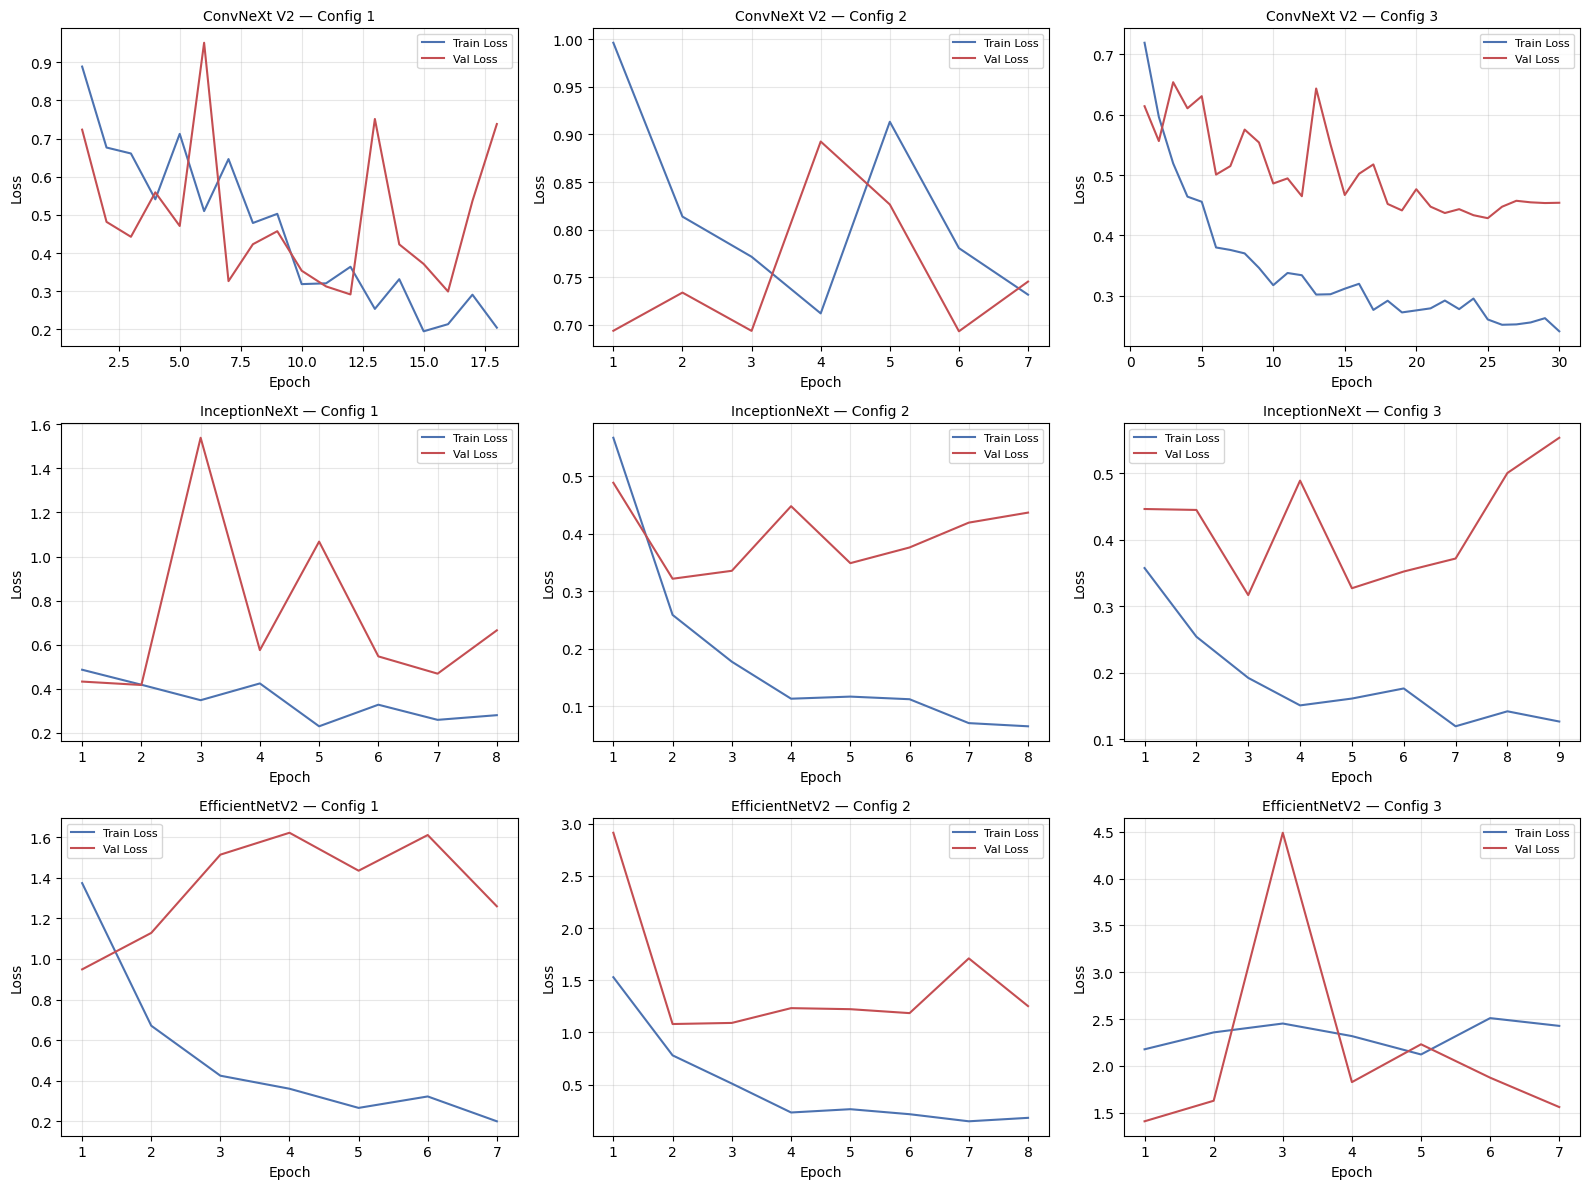

In [38]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for idx, result in enumerate(all_results):
    ax = axes[idx // 3][idx % 3]
    h = result["history"]
    epochs = range(1, len(h["train_loss"]) + 1)

    ax.plot(epochs, h["train_loss"], label="Train Loss", color="#4C72B0")
    ax.plot(epochs, h["val_loss"], label="Val Loss", color="#C44E52")
    ax.set_title(f"{result['model_name']} — Config {result['config_index']}", fontsize=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/loss_curves_all_configs.png", dpi=150)
plt.show()

###  Build the final comparison table

Flattens every entry in `all_results` into a row of a pandas DataFrame — model name, config index, hyperparameters, epochs run, training time, and all held-out test metrics (accuracy, F1, MCC, balanced accuracy, AUC-ROC). Prints the full table and saves it to `hyperparameter_comparison_all_models.csv` for reporting or further analysis, this is the table used to pick the best final model.

In [39]:
import pandas as pd

rows = []
for r in all_results:
    rows.append({
        "Model": r["model_name"],
        "Config #": r["config_index"],
        "LR": r["config"]["lr"],
        "Batch Size": r["config"]["batch_size"],
        "Weight Decay": r["config"]["weight_decay"],
        "Dropout": r["config"]["dropout"],
        "Optimizer": r["config"]["optimizer"],
        "Scheduler": r["config"]["scheduler"],
        "Epochs Run": r["epochs_run"],
        "Test Accuracy": r["test_accuracy"],
        "F1-score": r["test_f1"],
        "MCC": r["test_mcc"],
        "Balanced Acc": r["test_balanced_acc"],
        "AUC-ROC": r["test_auc_roc"],
        "Train Time (s)": round(r["training_time_sec"], 1),
    })

comparison_df = pd.DataFrame(rows)
pd.set_option('display.float_format', '{:.4f}'.format)
print(comparison_df.to_string(index=False))
comparison_df.to_csv("/content/hyperparameter_comparison_all_models.csv", index=False)

         Model  Config #     LR  Batch Size  Weight Decay  Dropout Optimizer Scheduler  Epochs Run  Test Accuracy  F1-score    MCC  Balanced Acc  AUC-ROC  Train Time (s)
   ConvNeXt V2         1 0.0004          64        0.0000   0.1367     adamw    cosine          18         0.9024    0.9397 0.7132        0.9239   0.9682        652.7000
   ConvNeXt V2         2 0.0009          64        0.0002   0.4172     adamw   plateau           7         0.1481    0.0000 0.0000        0.5000   0.3494        244.1000
   ConvNeXt V2         3 0.0005          32        0.0001   0.2300       sgd    cosine          30         0.9327    0.9605 0.7332        0.8666   0.9686       1080.5000
 InceptionNeXt         1 0.0013          64        0.0013   0.3559     adamw    cosine           8         0.8822    0.9266 0.6645        0.9027   0.9543        231.7000
 InceptionNeXt         2 0.0002          64        0.0000   0.4460     adamw   plateau           8         0.8721    0.9195 0.6557        0.9061   0.9

In [41]:
!ls /content/

ConvNeXt_V2_adamw_cosine_best.pth      hyperparameter_comparison_all_models.csv
ConvNeXt_V2_adamw_plateau_best.pth     InceptionNeXt_adamw_cosine_best.pth
ConvNeXt_V2_sgd_cosine_best.pth        InceptionNeXt_adamw_plateau_best.pth
drive				       InceptionNeXt_rmsprop_cosine_best.pth
EfficientNetV2_adamw_cosine_best.pth   loss_curves_all_configs.png
EfficientNetV2_adamw_plateau_best.pth  sample_data
EfficientNetV2_sgd_cosine_best.pth     sickle_cell_dataset


In [42]:
from google.colab import files
files.download("/content/ConvNeXt_V2_sgd_cosine_best.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
from google.colab import files
files.download(log_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>